In [1]:
# -*- coding: utf-8 -*-
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or
# implied.
# See the License for the specific language governing permissions and
# limitations under the License.
#

# Pandas = Panel Data
Pandas documentation: https://pandas.pydata.org/pandas-docs/version/0.17.0/10min.html

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Series

In [3]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

### DataFrame

In [4]:
dates = pd.date_range('20130101', periods=6)
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [5]:
df = pd.DataFrame(np.random.randn(6,4), index=dates, columns=list('ABCD'))
df

,A,B,C,D
2013-01-01,0.114822,-2.881878,-1.954849,-0.335453
2013-01-02,0.528226,0.341796,-2.728929,-0.064634
2013-01-03,0.006221,0.075374,-1.196006,-0.396203
2013-01-04,0.169421,-1.075817,0.236874,0.369218
2013-01-05,-0.056908,-0.428338,-1.102157,0.958149
2013-01-06,1.579762,1.105515,-0.935007,-0.010401


### Creating a DataFrame by passing a dict of objects

In [6]:
df2 = pd.DataFrame({ 'A' : 1.,
                     'B' : pd.Timestamp('20130102'),
                     'C' : pd.Series(1,index=list(range(4)),dtype='float32'),
                     'D' : np.array([3] * 4,dtype='int32'),
                     'E' : pd.Categorical(["test","train","test","train"]),
                     'F' : 'foo' })
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


# Viewing data

In [7]:
df2.dtypes

A          float64
B    datetime64[s]
C          float32
D            int32
E         category
F           object
dtype: object

In [8]:
df.head()

,A,B,C,D
2013-01-01,0.114822,-2.881878,-1.954849,-0.335453
2013-01-02,0.528226,0.341796,-2.728929,-0.064634
2013-01-03,0.006221,0.075374,-1.196006,-0.396203
2013-01-04,0.169421,-1.075817,0.236874,0.369218
2013-01-05,-0.056908,-0.428338,-1.102157,0.958149


In [9]:
df.tail(2)

,A,B,C,D
2013-01-05,-0.056908,-0.428338,-1.102157,0.958149
2013-01-06,1.579762,1.105515,-0.935007,-0.010401


In [10]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,0.390257,-0.477225,-1.280012,0.086779
std,0.617419,1.387392,1.001342,0.506553
min,-0.056908,-2.881878,-2.728929,-0.396203
25%,0.033371,-0.913948,-1.765138,-0.267749
50%,0.142122,-0.176482,-1.149082,-0.037518
75%,0.438524,0.275191,-0.976794,0.274313
max,1.579762,1.105515,0.236874,0.958149


In [11]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

# Transposing data

In [12]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,0.114822,0.528226,0.006221,0.169421,-0.056908,1.579762
B,-2.881878,0.341796,0.075374,-1.075817,-0.428338,1.105515
C,-1.954849,-2.728929,-1.196006,0.236874,-1.102157,-0.935007
D,-0.335453,-0.064634,-0.396203,0.369218,0.958149,-0.010401


# Data selection

**One column = Series**

In [13]:
print(type(df['A']))
df['A']

<class 'pandas.core.series.Series'>


2013-01-01    0.114822
2013-01-02    0.528226
2013-01-03    0.006221
2013-01-04    0.169421
2013-01-05   -0.056908
2013-01-06    1.579762
Freq: D, Name: A, dtype: float64

**Slicing**

In [14]:
df[0:3]

,A,B,C,D
2013-01-01,0.114822,-2.881878,-1.954849,-0.335453
2013-01-02,0.528226,0.341796,-2.728929,-0.064634
2013-01-03,0.006221,0.075374,-1.196006,-0.396203


**Selection by label**

In [15]:
df.loc[dates[0]]

A    0.114822
B   -2.881878
C   -1.954849
D   -0.335453
Name: 2013-01-01 00:00:00, dtype: float64

In [16]:
df.loc[:,['A','B']]

,A,B
2013-01-01,0.114822,-2.881878
2013-01-02,0.528226,0.341796
2013-01-03,0.006221,0.075374
2013-01-04,0.169421,-1.075817
2013-01-05,-0.056908,-0.428338
2013-01-06,1.579762,1.105515


**Selection by Position**

In [17]:
df.iloc[1,1]

np.float64(0.34179618787052646)

In [18]:
df.iloc[3:5,0:2]

,A,B
2013-01-04,0.169421,-1.075817
2013-01-05,-0.056908,-0.428338


**Boolean Indexing**

In [19]:
df[df.A > 0]

,A,B,C,D
2013-01-01,0.114822,-2.881878,-1.954849,-0.335453
2013-01-02,0.528226,0.341796,-2.728929,-0.064634
2013-01-03,0.006221,0.075374,-1.196006,-0.396203
2013-01-04,0.169421,-1.075817,0.236874,0.369218
2013-01-06,1.579762,1.105515,-0.935007,-0.010401


In [20]:
df[df > 0]

,A,B,C,D
2013-01-01,0.114822,NaN,NaN,NaN
2013-01-02,0.528226,0.341796,NaN,NaN
2013-01-03,0.006221,0.075374,NaN,NaN
2013-01-04,0.169421,NaN,0.236874,0.369218
2013-01-05,NaN,NaN,NaN,0.958149
2013-01-06,1.579762,1.105515,NaN,NaN


**Setting values ​​by label**

In [21]:
df.at[dates[0],'A'] = 0
df

,A,B,C,D
2013-01-01,0.000000,-2.881878,-1.954849,-0.335453
2013-01-02,0.528226,0.341796,-2.728929,-0.064634
2013-01-03,0.006221,0.075374,-1.196006,-0.396203
2013-01-04,0.169421,-1.075817,0.236874,0.369218
2013-01-05,-0.056908,-0.428338,-1.102157,0.958149
2013-01-06,1.579762,1.105515,-0.935007,-0.010401


# Missing Data

In [22]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ['E'])
df1

,A,B,C,D,E
2013-01-01,0.000000,-2.881878,-1.954849,-0.335453,NaN
2013-01-02,0.528226,0.341796,-2.728929,-0.064634,NaN
2013-01-03,0.006221,0.075374,-1.196006,-0.396203,NaN
2013-01-04,0.169421,-1.075817,0.236874,0.369218,NaN


In [23]:
df1.loc[dates[0]:dates[1],'E'] = 1
df1

,A,B,C,D,E
2013-01-01,0.000000,-2.881878,-1.954849,-0.335453,1.0
2013-01-02,0.528226,0.341796,-2.728929,-0.064634,1.0
2013-01-03,0.006221,0.075374,-1.196006,-0.396203,NaN
2013-01-04,0.169421,-1.075817,0.236874,0.369218,NaN


In [24]:
df1.dropna(how='any')

,A,B,C,D,E
2013-01-01,0.000000,-2.881878,-1.954849,-0.335453,1.0
2013-01-02,0.528226,0.341796,-2.728929,-0.064634,1.0


In [25]:
df1.fillna(value=5)

,A,B,C,D,E
2013-01-01,0.000000,-2.881878,-1.954849,-0.335453,1.0
2013-01-02,0.528226,0.341796,-2.728929,-0.064634,1.0
2013-01-03,0.006221,0.075374,-1.196006,-0.396203,5.0
2013-01-04,0.169421,-1.075817,0.236874,0.369218,5.0


**Boolean mask where values ​​are NaN**

In [26]:
pd.isnull(df1)

,A,B,C,D,E
2013-01-01,False,False,False,False,False
2013-01-02,False,False,False,False,False
2013-01-03,False,False,False,False,True
2013-01-04,False,False,False,False,True


# Operations

In [27]:
df.mean()

A    0.371120
B   -0.477225
C   -1.280012
D    0.086779
dtype: float64

In [28]:
df.mean(axis=0)
# df.mean(axis=1)

A    0.371120
B   -0.477225
C   -1.280012
D    0.086779
dtype: float64

### Applying functions to the data

In [29]:
df.apply(np.cumsum)

,A,B,C,D
2013-01-01,0.000000,-2.881878,-1.954849,-0.335453
2013-01-02,0.528226,-2.540082,-4.683778,-0.400088
2013-01-03,0.534447,-2.464707,-5.879784,-0.796291
2013-01-04,0.703868,-3.540525,-5.642911,-0.427073
2013-01-05,0.646959,-3.968862,-6.745067,0.531076
2013-01-06,2.226722,-2.863348,-7.680074,0.520674


In [30]:
df.apply(lambda x: x.max() - x.min())

A    1.636671
B    3.987392
C    2.965803
D    1.354352
dtype: float64

# Merging data

## Concat

In [31]:
df = pd.DataFrame(np.random.randn(10, 4))
df

,0,1,2,3
0,-0.118530,0.374666,-1.513965,-1.475727
1,-0.137848,0.239766,-0.587348,0.779625
2,-0.347910,-0.821544,1.516444,0.903514
3,-0.246126,-0.930073,-0.574566,-1.035055
4,-0.240302,0.719410,0.018224,-1.018121
5,-0.183533,0.991197,-0.733424,1.038283
6,-1.035594,0.720541,-1.440224,-0.769445
7,-1.420844,0.873694,1.267028,0.589706
8,-0.136350,-0.202636,-0.120646,3.789372
9,0.100791,-0.292943,-1.548297,-1.645135


In [32]:
pieces = [df[:3], df[3:7], df[7:]]
pieces

[          0         1         2         3
 0 -0.118530  0.374666 -1.513965 -1.475727
 1 -0.137848  0.239766 -0.587348  0.779625
 2 -0.347910 -0.821544  1.516444  0.903514,
           0         1         2         3
 3 -0.246126 -0.930073 -0.574566 -1.035055
 4 -0.240302  0.719410  0.018224 -1.018121
 5 -0.183533  0.991197 -0.733424  1.038283
 6 -1.035594  0.720541 -1.440224 -0.769445,
           0         1         2         3
 7 -1.420844  0.873694  1.267028  0.589706
 8 -0.136350 -0.202636 -0.120646  3.789372
 9  0.100791 -0.292943 -1.548297 -1.645135]

In [33]:
len(pieces)

3

In [34]:
pieces[1]

,0,1,2,3
3,-0.246126,-0.930073,-0.574566,-1.035055
4,-0.240302,0.719410,0.018224,-1.018121
5,-0.183533,0.991197,-0.733424,1.038283
6,-1.035594,0.720541,-1.440224,-0.769445


In [35]:
pd.concat(pieces)


,0,1,2,3
0,-0.118530,0.374666,-1.513965,-1.475727
1,-0.137848,0.239766,-0.587348,0.779625
2,-0.347910,-0.821544,1.516444,0.903514
3,-0.246126,-0.930073,-0.574566,-1.035055
4,-0.240302,0.719410,0.018224,-1.018121
5,-0.183533,0.991197,-0.733424,1.038283
6,-1.035594,0.720541,-1.440224,-0.769445
7,-1.420844,0.873694,1.267028,0.589706
8,-0.136350,-0.202636,-0.120646,3.789372
9,0.100791,-0.292943,-1.548297,-1.645135


## Join

In [36]:
left = pd.DataFrame({'key': ['k1', 'k2'], 'lval': [1, 2]})
left

,key,lval
0,k1,1
1,k2,2


In [37]:
right = pd.DataFrame({'key': ['k1', 'k2'], 'rval': [3, 4]})
right

,key,rval
0,k1,3
1,k2,4


In [38]:
pd.merge(left, right, on='key')

,key,lval,rval
0,k1,1,3
1,k2,2,4


## Grouping

In [39]:
df = pd.DataFrame({'A' : ['foo', 'bar', 'foo', 'bar',
                          'foo', 'bar', 'foo', 'foo'],
                   'B' : ['one', 'one', 'two', 'three',
                          'two', 'two', 'one', 'three'],
                   'C' : np.random.randn(8),
                   'D' : np.random.randn(8)})
df

,A,B,C,D
0,foo,one,-0.347842,0.217422
1,bar,one,-0.607689,0.675811
2,foo,two,-0.214767,0.555993
3,bar,three,-1.502723,-0.588065
4,foo,two,1.327717,-1.228407
5,bar,two,-0.757600,1.121258
6,foo,one,0.423924,0.936893
7,foo,three,0.207728,-0.622331


In [40]:
df.groupby('A').sum()

,B,C,D
A,,,
bar,onethreetwo,-2.868012,1.209004
foo,onetwotwoonethree,1.396759,-0.140430


In [41]:
df.groupby(['A','B']).sum()

C         D
A   B                        
bar one   -0.607689  0.675811
    three -1.502723 -0.588065
    two   -0.757600  1.121258
foo one    0.076081  1.154315
    three  0.207728 -0.622331
    two    1.112950 -0.672414

## Reshaping

### Stack

In [42]:
tuples = list(zip(*[['bar', 'bar', 'baz', 'baz',
                     'foo', 'foo', 'qux', 'qux'],
                    ['one', 'two', 'one', 'two',
                     'one', 'two', 'one', 'two']]))
tuples

[('bar', 'one'),
 ('bar', 'two'),
 ('baz', 'one'),
 ('baz', 'two'),
 ('foo', 'one'),
 ('foo', 'two'),
 ('qux', 'one'),
 ('qux', 'two')]

In [43]:
index = pd.MultiIndex.from_tuples(tuples, names=['first', 'second'])
index

MultiIndex([('bar', 'one'),
            ('bar', 'two'),
            ('baz', 'one'),
            ('baz', 'two'),
            ('foo', 'one'),
            ('foo', 'two'),
            ('qux', 'one'),
            ('qux', 'two')],
           names=['first', 'second'])

In [44]:
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=['A', 'B'])
df

A         B
first second                    
bar   one    -0.166475  0.971960
      two    -0.282683 -0.228877
baz   one     0.075313 -0.391929
      two    -0.049607 -0.044455
foo   one     0.469293  0.361860
      two     1.715447  0.116563
qux   one    -1.012478 -1.425597
      two     1.709900 -2.039653

In [45]:
df2 = df[:4]
df2

A         B
first second                    
bar   one    -0.166475  0.971960
      two    -0.282683 -0.228877
baz   one     0.075313 -0.391929
      two    -0.049607 -0.044455

In [46]:
stacked = df2.stack()
stacked

first  second   
bar    one     A   -0.166475
               B    0.971960
       two     A   -0.282683
               B   -0.228877
baz    one     A    0.075313
               B   -0.391929
       two     A   -0.049607
               B   -0.044455
dtype: float64

In [47]:
stacked.shape

(8,)

**With a “stacked” DataFrame or Series (having a MultiIndex as the index), the inverse operation of stack() is unstack(), which by default unstacks the last level:**

In [48]:
stacked.unstack()

A         B
first second                    
bar   one    -0.166475  0.971960
      two    -0.282683 -0.228877
baz   one     0.075313 -0.391929
      two    -0.049607 -0.044455

### Pivot Tables

In [49]:
df = pd.DataFrame({'A' : ['one', 'one', 'two', 'three'] * 3,
                   'B' : ['A', 'B', 'C'] * 4,
                   'C' : ['foo', 'foo', 'foo', 'bar', 'bar', 'bar'] * 2,
                   'D' : np.random.randn(12),
                   'E' : np.random.randn(12)})
df

,A,B,C,D,E
0,one,A,foo,-0.546443,-1.453951
1,one,B,foo,0.848347,-0.339236
2,two,C,foo,-0.115818,-0.632698
3,three,A,bar,-0.684917,0.428913
4,one,B,bar,1.899176,0.229843
5,one,C,bar,-1.055670,2.159967
6,two,A,foo,0.846395,-2.494621
7,three,B,foo,2.166118,0.231961
8,one,C,foo,0.913546,0.721829
9,one,A,bar,0.082775,0.553016


In [50]:
pd.pivot_table(df, values='D', index=['A', 'B'], columns=['C'])

C             bar       foo
A     B                    
one   A  0.082775 -0.546443
      B  1.899176  0.848347
      C -1.055670  0.913546
three A -0.684917       NaN
      B       NaN  2.166118
      C  0.401190       NaN
two   A       NaN  0.846395
      B  0.352114       NaN
      C       NaN -0.115818

# Time Series

In [51]:
rng = pd.date_range('1/1/2012', periods=100, freq='S')
rng

C:\Users\Andrii\AppData\Local\Temp\ipykernel_17492\2150156700.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range('1/1/2012', periods=100, freq='S')


DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 00:00:01',
               '2012-01-01 00:00:02', '2012-01-01 00:00:03',
               '2012-01-01 00:00:04', '2012-01-01 00:00:05',
               '2012-01-01 00:00:06', '2012-01-01 00:00:07',
               '2012-01-01 00:00:08', '2012-01-01 00:00:09',
               '2012-01-01 00:00:10', '2012-01-01 00:00:11',
               '2012-01-01 00:00:12', '2012-01-01 00:00:13',
               '2012-01-01 00:00:14', '2012-01-01 00:00:15',
               '2012-01-01 00:00:16', '2012-01-01 00:00:17',
               '2012-01-01 00:00:18', '2012-01-01 00:00:19',
               '2012-01-01 00:00:20', '2012-01-01 00:00:21',
               '2012-01-01 00:00:22', '2012-01-01 00:00:23',
               '2012-01-01 00:00:24', '2012-01-01 00:00:25',
               '2012-01-01 00:00:26', '2012-01-01 00:00:27',
               '2012-01-01 00:00:28', '2012-01-01 00:00:29',
               '2012-01-01 00:00:30', '2012-01-01 00:00:31',
               '2012-01-

In [52]:
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts

2012-01-01 00:00:00    230
2012-01-01 00:00:01    346
2012-01-01 00:00:02    224
2012-01-01 00:00:03     59
2012-01-01 00:00:04    370
                      ... 
2012-01-01 00:01:35    280
2012-01-01 00:01:36    224
2012-01-01 00:01:37    311
2012-01-01 00:01:38    455
2012-01-01 00:01:39     38
Freq: s, Length: 100, dtype: int32

In [53]:
ts.resample('5Min').sum()

2012-01-01    23086
Freq: 5min, dtype: int32

In [54]:
rng = pd.date_range('3/6/2012 00:00', periods=5, freq='D')
rng

DatetimeIndex(['2012-03-06', '2012-03-07', '2012-03-08', '2012-03-09',
               '2012-03-10'],
              dtype='datetime64[ns]', freq='D')

In [55]:
ts = pd.Series(np.random.randn(len(rng)), rng)
ts

2012-03-06    0.455431
2012-03-07    0.579382
2012-03-08   -0.974435
2012-03-09    2.279897
2012-03-10    0.282034
Freq: D, dtype: float64

In [56]:
ts_utc = ts.tz_localize('UTC')
ts_utc

2012-03-06 00:00:00+00:00    0.455431
2012-03-07 00:00:00+00:00    0.579382
2012-03-08 00:00:00+00:00   -0.974435
2012-03-09 00:00:00+00:00    2.279897
2012-03-10 00:00:00+00:00    0.282034
Freq: D, dtype: float64

# Categoricals

In [57]:
df = pd.DataFrame({"id":[1,2,3,4,5,6], "raw_grade":['a', 'b', 'b', 'a', 'a', 'e']})
df

,id,raw_grade
0,1,a
1,2,b
2,3,b
3,4,a
4,5,a
5,6,e


In [58]:
df["grade"] = df["raw_grade"].astype("category")
df["grade"]

0    a
1    b
2    b
3    a
4    a
5    e
Name: grade, dtype: category
Categories (3, object): ['a', 'b', 'e']

In [59]:
df["verbal_grade"] = df["grade"].cat.rename_categories(["bad", "good", "very good"])
df["verbal_grade"]

0          bad
1         good
2         good
3          bad
4          bad
5    very good
Name: verbal_grade, dtype: category
Categories (3, object): ['bad', 'good', 'very good']

In [60]:
df.sort_values(by="grade")

,id,raw_grade,grade,verbal_grade
0,1,a,a,bad
3,4,a,a,bad
4,5,a,a,bad
1,2,b,b,good
2,3,b,b,good
5,6,e,e,very good


In [61]:
df.groupby("grade").size()

C:\Users\Andrii\AppData\Local\Temp\ipykernel_17492\3951628473.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("grade").size()


grade
a    3
b    2
e    1
dtype: int64

# Plotting

In [62]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000))
ts

2000-01-01    1.621575
2000-01-02    0.128423
2000-01-03    0.142182
2000-01-04    0.302071
2000-01-05    2.815022
                ...   
2002-09-22    0.585956
2002-09-23    1.194186
2002-09-24   -0.055451
2002-09-25    0.266021
2002-09-26    0.887418
Freq: D, Length: 1000, dtype: float64

In [63]:
ts = ts.cumsum()
ts

2000-01-01     1.621575
2000-01-02     1.749998
2000-01-03     1.892180
2000-01-04     2.194251
2000-01-05     5.009273
                ...    
2002-09-22    86.275858
2002-09-23    87.470044
2002-09-24    87.414592
2002-09-25    87.680613
2002-09-26    88.568032
Freq: D, Length: 1000, dtype: float64

<Axes: >

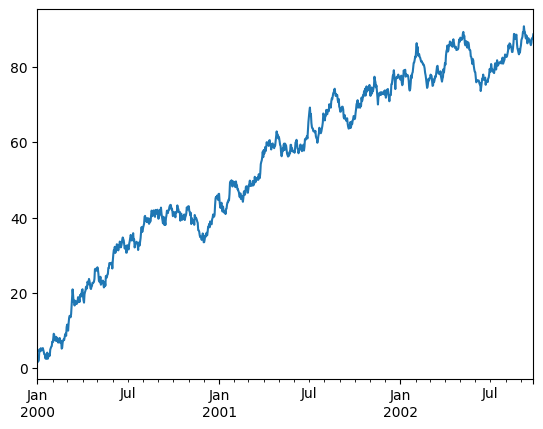

In [64]:
ts.plot()

In [65]:
df = pd.DataFrame(np.random.randn(1000, 4), index=ts.index,
                  columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
2000-01-01,-1.380321,-0.665784,-0.726128,-0.026388
2000-01-02,-1.061391,0.702733,0.152489,-0.877386
2000-01-03,-0.782472,-0.673845,0.947732,-0.095258
2000-01-04,-1.474672,0.122058,-0.341091,1.108918
2000-01-05,-0.153518,-0.198165,1.496270,-1.123658
...,...,...,...,...
2002-09-22,-1.075129,-0.879888,-1.559251,1.303668
2002-09-23,-1.076571,1.045848,-1.042024,0.128913
2002-09-24,1.725705,-0.726249,-1.010879,1.058218
2002-09-25,-0.377381,0.079086,-1.298870,-0.007157


In [66]:
df = df.cumsum()
df

,A,B,C,D
2000-01-01,-1.380321,-0.665784,-0.726128,-0.026388
2000-01-02,-2.441712,0.036949,-0.573639,-0.903775
2000-01-03,-3.224184,-0.636896,0.374093,-0.999032
2000-01-04,-4.698856,-0.514838,0.033002,0.109886
2000-01-05,-4.852374,-0.713003,1.529271,-1.013773
...,...,...,...,...
2002-09-22,39.691496,-4.733144,-28.349728,13.845315
2002-09-23,38.614925,-3.687296,-29.391752,13.974228
2002-09-24,40.340630,-4.413545,-30.402631,15.032446
2002-09-25,39.963250,-4.334458,-31.701501,15.025289


<Figure size 640x480 with 0 Axes>

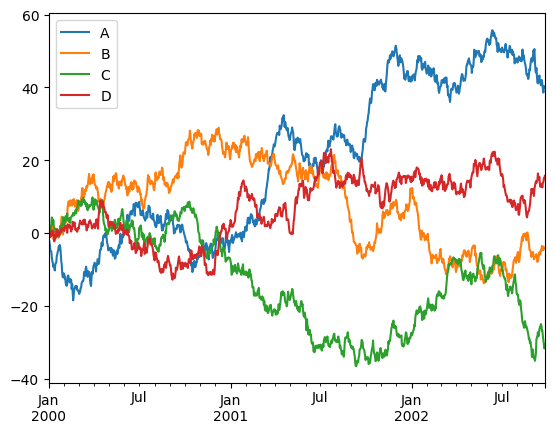

In [67]:
plt.figure() 
df.plot() 
plt.legend(loc='best')

# 100-pandas-puzzles

**https://github.com/FIIT-IAU/100-pandas-puzzles** (forked from https://github.com/ajcr/100-pandas-puzzles)